In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("../data/processed/nba_stats_clean.csv")

In [3]:
df_sf = df[df['pos'] == 'SF'].copy()

print("Nombre de SF :", df_sf.shape[0])

Nombre de SF : 1279


On utilise les statistiques présélectionnées.

In [4]:
sf_stats = [
    "usg_percent",
    "ast_percent",
    "x3p_ar",
    "ts_percent",
    "drb_percent",
    "orb_percent",
    "stl_percent",
    "blk_percent"
]
X_sf = df_sf[sf_stats]

On met les stastiques à la même échelle avant d'éviter une influence excessive des données brutes des données relatives. 

In [5]:
scaler = StandardScaler()
X_sf_scaled = scaler.fit_transform(X_sf)

On utilise les PCA (Principal Component Analysis) pour résumer les statistiques utilisés en quelques axes synthétiques et ainsi pouvoir visualiser quelles statistiques permettent de classer les joueurs. On fixe la variance cumulée au moins à 0,7 afin d'être suffisament précis pour classer les joueurs de façons pertinentes sans rentrer dans des groupes ultra spécifiques. 

In [6]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()
pca.fit(X_sf_scaled)

explained_var = pca.explained_variance_ratio_

cumulative_var = np.cumsum(explained_var)

print(explained_var)
print(cumulative_var)

[0.27398033 0.21246497 0.13687955 0.11164945 0.09008686 0.08220873
 0.04918891 0.04354121]
[0.27398033 0.4864453  0.62332485 0.7349743  0.82506116 0.90726989
 0.95645879 1.        ]


On utilisera donc 4 PCA pour les SF .

In [7]:
pca = PCA(n_components=4, random_state=42)
pca_result = pca.fit_transform(X_sf_scaled)

loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PCA{i+1}' for i in range(pca.n_components_)],
    index=sf_stats
)

print("Loadings PCA :")
print(loadings)

Loadings PCA :
                 PCA1      PCA2      PCA3      PCA4
usg_percent -0.378470  0.492790 -0.162373 -0.035140
ast_percent -0.385571  0.495813  0.007618  0.184459
x3p_ar       0.464676  0.103906  0.476297  0.125118
ts_percent  -0.026312  0.309997  0.711052 -0.301952
drb_percent -0.449967 -0.019266  0.174830 -0.265409
orb_percent -0.345450 -0.479095 -0.001939 -0.327309
stl_percent -0.292335 -0.189055  0.235527  0.824825
blk_percent -0.290197 -0.372543  0.393803 -0.001276


On cherche à determiner le nombre de clusters le plus pertinent pour le poste à l'aide de la méthode du coude et du score de silouhette .

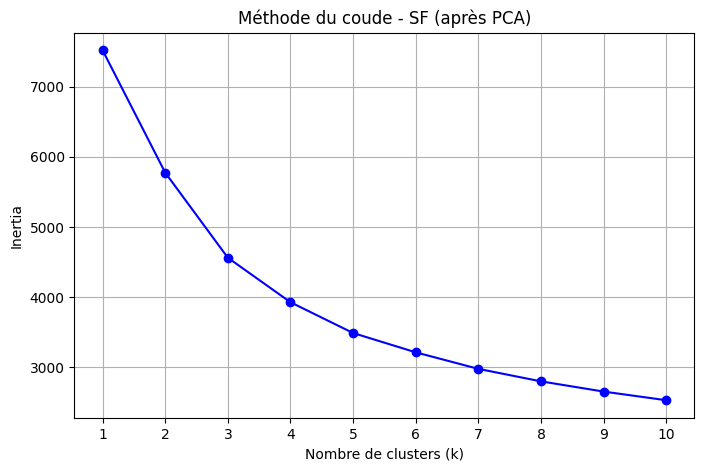

In [8]:
inertia_list = []

k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    kmeans.fit(pca_result)   # <- utilisation de pca_result
    inertia_list.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, inertia_list, 'o-', color='blue')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertia")
plt.title("Méthode du coude - SF (après PCA)")
plt.xticks(k_values)
plt.grid(True)
plt.show()


In [9]:
inertia_df = pd.DataFrame({'k': k_values, 'inertia': inertia_list})
inertia_df

,k,inertia
0,1,7520.257029
1,2,5774.703615
2,3,4561.729023
3,4,3927.068333
4,5,3488.118378
5,6,3212.861610
6,7,2976.974760
7,8,2798.944233
8,9,2653.117336
9,10,2529.879399


In [10]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import pandas as pd

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(pca_result)  # <- utiliser le résultat PCA
    score = silhouette_score(pca_result, labels)
    silhouette_scores.append(score)

silhouette_df = pd.DataFrame({
    'k': range(2, 11),
    'silhouette_score': silhouette_scores
})

silhouette_df


,k,silhouette_score
0,2,0.214174
1,3,0.241764
2,4,0.215623
3,5,0.215972
4,6,0.214058
5,7,0.198149
6,8,0.189484
7,9,0.190364
8,10,0.183059


La méthode du coude nous indique un nombre de clusters pertinent entre 3 et 4, et le score de silouhette, bien que faible ce qui est normal pour un score comme le basket due à la diversité des postes, mais également des roles par poste, est pertinent pour 4 clusters, on choisit donc un nombre de cluster de 4.

In [11]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
df_sf['cluster'] = kmeans.fit_predict(pca_result)

In [12]:
cluster_means = df_sf.groupby('cluster')[sf_stats].mean()
cluster_means

,usg_percent,ast_percent,x3p_ar,ts_percent,drb_percent,orb_percent,stl_percent,blk_percent
cluster,,,,,,,,
0,17.838539,9.517128,0.346040,0.508297,12.932997,3.757431,1.590932,1.092191
1,16.262000,8.993500,0.578078,0.568377,11.962250,2.528250,1.356500,0.970250
2,16.363754,9.246602,0.350835,0.551780,16.076375,5.550485,1.903560,2.100000
3,26.243353,21.218497,0.306491,0.571983,16.241040,3.284393,1.731792,1.267630


Cluster 0 — Forward polyvalent
Usage offensif moyen.Contribution équilibrée dans plusieurs domaines.Apporte rebonds et défense sans être une option offensive principale.
Cluster 1 — Stretch Forward
Forte proportion de tirs à 3 points.Bonne efficacité offensive (TS%).Faible impact au rebond et en protection du cercle.
Cluster 2 — Forward défensif / rebondeur
Très forte contribution au rebond (offensif et défensif).Impact défensif important (interceptions et contres).Jeu offensif plus limité.
Cluster 3 — Star Forward / créateur
Usage offensif très élevé.Très forte création de jeu (AST%).Bonne efficacité offensive et contribution globale.

In [13]:
import plotly.express as px
import pandas as pd

plot_df = pd.DataFrame({
    'PCA1': pca_result[:, 0],
    'PCA2': pca_result[:, 1],
    'cluster': df_sf['cluster'],
    'player': df_sf['player'],
    'team': df_sf['team'],
    'season': df_sf['season']
})

fig = px.scatter(
    plot_df,
    x='PCA1',
    y='PCA2',
    color='cluster',
    hover_data=['player', 'team', 'season'],
    title="Clusters SF (PCA1 vs PCA2)",
    width=900,
    height=600
)

fig.show()


In [14]:
df_sf['cluster'] = kmeans.fit_predict(pca_result)

df_sf.to_csv("../data/processed/nba_sf_clusters_full.csv", index=False)

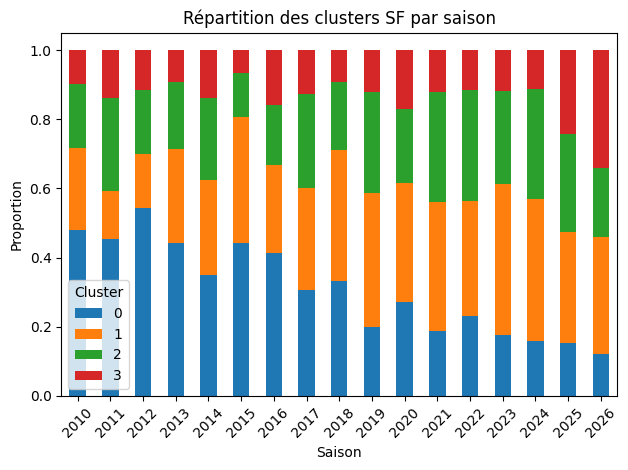

In [15]:
import pandas as pd
import matplotlib.pyplot as plt


df_sf = pd.read_csv("../data/processed/nba_sf_clusters_full.csv")


counts = df_sf.groupby(['season', 'cluster']).size().reset_index(name='count')


totals = df_sf.groupby('season').size().reset_index(name='total')


counts = counts.merge(totals, on='season')
counts['proportion'] = counts['count'] / counts['total']


pivot = counts.pivot(index='season', columns='cluster', values='proportion')

pivot.plot(kind='bar', stacked=True)

plt.title("Répartition des clusters SF par saison")
plt.xlabel("Saison")
plt.ylabel("Proportion")
plt.legend(title="Cluster")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
On constate une nette évolution des profils ces 15 dernières années. Les SF de type 3 étaient infimes durant 13 ans, puis sont devenues très présents ces deux dernière années. 
ceux de type 2 sont restés constant et ceux de type 1 sont légérements plus représentés. En revanche, les SF de type 0 sont passés de majoritaires à minoritaires de façon très progressive sur 15 ans, jusqu'à n'en rester que quelques un aujourdh'hui.